# 18 · Calibration Workflows

Finstack ships a calibration helper that ingests market quotes, solves curves, and returns enriched `MarketContext` objects. This notebook wires the test quote set into `SimpleCalibration`.

### Learning Objectives
- Load reusable quote sets (rates, forwards, credit, vols)
- Configure `SimpleCalibration` with solver options
- Inspect calibration reports and derived market data

In [1]:
from datetime import date

from finstack.core.market_data import MarketContext
from finstack.valuations import calibration as cal

# Always define base_date - Bloomberg settle date
base_date = date(2025, 12, 10)


## 1. Discount Curve Calibration
We start by calibrating a USD-OIS discount curve directly with `DiscountCurveCalibrator`. The helper returns market quotes, so we recreate the short deposit and swap points inline before bootstrapping.

In [2]:
# Bloomberg USD OIS curve data (Settle: 12/10/2025)
# Short-end deposits (< 1Y) and OIS swaps (>= 1Y)

DEPOSIT_INDEX_ID = "USD-DEPOSIT"
OIS_INDEX_ID = "USD-FEDFUNDS-OIS"

discount_quotes = [
    # Short-term deposits - using actual maturity dates from Bloomberg
    cal.RatesQuote.deposit("DEPO-1W", DEPOSIT_INDEX_ID, date(2025, 12, 19), 0.0364447),
    cal.RatesQuote.deposit("DEPO-2W", DEPOSIT_INDEX_ID, date(2025, 12, 26), 0.0364455),
    cal.RatesQuote.deposit("DEPO-3W", DEPOSIT_INDEX_ID, date(2026, 1, 2), 0.0365300),
    cal.RatesQuote.deposit("DEPO-1M", DEPOSIT_INDEX_ID, date(2026, 1, 12), 0.0364950),
    cal.RatesQuote.deposit("DEPO-2M", DEPOSIT_INDEX_ID, date(2026, 2, 12), 0.0364050),
    cal.RatesQuote.deposit("DEPO-3M", DEPOSIT_INDEX_ID, date(2026, 3, 12), 0.0363477),
    cal.RatesQuote.deposit("DEPO-4M", DEPOSIT_INDEX_ID, date(2026, 4, 13), 0.0361400),
    cal.RatesQuote.deposit("DEPO-5M", DEPOSIT_INDEX_ID, date(2026, 5, 12), 0.0359544),
    cal.RatesQuote.deposit("DEPO-6M", DEPOSIT_INDEX_ID, date(2026, 6, 12), 0.0358000),
    cal.RatesQuote.deposit("DEPO-7M", DEPOSIT_INDEX_ID, date(2026, 7, 13), 0.0355310),
    cal.RatesQuote.deposit("DEPO-8M", DEPOSIT_INDEX_ID, date(2026, 8, 12), 0.0352500),
    cal.RatesQuote.deposit("DEPO-9M", DEPOSIT_INDEX_ID, date(2026, 9, 14), 0.0350225),
    cal.RatesQuote.deposit("DEPO-10M", DEPOSIT_INDEX_ID, date(2026, 10, 13), 0.0347742),
    cal.RatesQuote.deposit("DEPO-11M", DEPOSIT_INDEX_ID, date(2026, 11, 12), 0.0345356),
    # OIS Swaps (>= 1Y)
    cal.RatesQuote.swap("OIS-1Y", OIS_INDEX_ID, date(2026, 12, 14), 0.0343446),
    cal.RatesQuote.swap("OIS-18M", OIS_INDEX_ID, date(2027, 6, 14), 0.0332849),
    cal.RatesQuote.swap("OIS-2Y", OIS_INDEX_ID, date(2027, 12, 13), 0.0329864),
    cal.RatesQuote.swap("OIS-3Y", OIS_INDEX_ID, date(2028, 12, 12), 0.0330190),
    cal.RatesQuote.swap("OIS-4Y", OIS_INDEX_ID, date(2029, 12, 12), 0.0333823),
    cal.RatesQuote.swap("OIS-5Y", OIS_INDEX_ID, date(2030, 12, 12), 0.0338799),
    cal.RatesQuote.swap("OIS-6Y", OIS_INDEX_ID, date(2031, 12, 12), 0.0344608),
    cal.RatesQuote.swap("OIS-7Y", OIS_INDEX_ID, date(2032, 12, 13), 0.0350619),
    cal.RatesQuote.swap("OIS-8Y", OIS_INDEX_ID, date(2033, 12, 12), 0.0356592),
    cal.RatesQuote.swap("OIS-9Y", OIS_INDEX_ID, date(2034, 12, 12), 0.0362453),
    cal.RatesQuote.swap("OIS-10Y", OIS_INDEX_ID, date(2035, 12, 12), 0.0368206),
    cal.RatesQuote.swap("OIS-12Y", OIS_INDEX_ID, date(2037, 12, 14), 0.0378975),
    cal.RatesQuote.swap("OIS-15Y", OIS_INDEX_ID, date(2040, 12, 12), 0.0391717),
    cal.RatesQuote.swap("OIS-20Y", OIS_INDEX_ID, date(2045, 12, 12), 0.0402348),
    cal.RatesQuote.swap("OIS-25Y", OIS_INDEX_ID, date(2050, 12, 12), 0.0403809),
    cal.RatesQuote.swap("OIS-30Y", OIS_INDEX_ID, date(2055, 12, 13), 0.0401000),
    cal.RatesQuote.swap("OIS-40Y", OIS_INDEX_ID, date(2065, 12, 14), 0.0390413),
    cal.RatesQuote.swap("OIS-50Y", OIS_INDEX_ID, date(2075, 12, 12), 0.0378761),
]

# --- Calibration method toggle ---
# Keep Bootstrap as default; optionally switch to GlobalSolve (global multi-instrument solve).
USE_GLOBAL_SOLVE = True
USE_ANALYTICAL_JACOBIAN = True

market = MarketContext()

calibration_method = (
    cal.CalibrationMethod.from_name("global_solve", use_analytical_jacobian=USE_ANALYTICAL_JACOBIAN)
    if USE_GLOBAL_SOLVE
    else cal.CalibrationMethod.BOOTSTRAP
)

# `execute_calibration_v2` expects JSON-serializable step definitions.
method_json = (
    {"GlobalSolve": {"use_analytical_jacobian": USE_ANALYTICAL_JACOBIAN}} if USE_GLOBAL_SOLVE else "Bootstrap"
)
print("method:", method_json)

# Step-level pricing + curve-time-axis conventions (deterministic, vendor-style).
disc_step_conventions = {
    "curve_day_count": "act365f",
    "use_settlement_start": True,    
    "settlement_days": 2,
    "calendar_id": "usny",
    "business_day_convention": "modified_following",
    "allow_calendar_fallback": False,
}

quote_sets = {"ois": [q.to_market_quote() for q in discount_quotes]}
steps = [
    {
        "id": "disc",
        "quote_set": "ois",
        "kind": "discount",
        "curve_id": "USD-OIS",
        "currency": "USD",
        "base_date": str(base_date),
        "method": method_json,
        "conventions": disc_step_conventions,
        "interpolation": "piecewise_quadratic_forward",
        "extrapolation": "flat_forward",
    }
]

settings = cal.CalibrationConfig(
    # GlobalSolve tolerance applies to the L2 norm of weighted PV residuals (per notional).
    # Use ~1e-12 for near-machine-precision fits; looser values may stop early.
    tolerance=1e-12,
)

market, plan_report, step_reports = cal.execute_calibration_v2(
    "notebook_discount_curve",
    quote_sets,
    steps,
    settings=settings,
)

discount_curve = market.discount("USD-OIS")
discount_report = step_reports["disc"]
print("Discount curve calibrated:", discount_curve.id)
print("Calibration method:", calibration_method.name)
print("Plan success:", plan_report.success)
print("Step success:", discount_report.success)
print("Max residual:", discount_report.max_residual)
print("RMSE:", discount_report.rmse)
print("Number of knots:", len(discount_curve.points))

# Quick residual diagnostic: which instrument(s) are driving the fit error?
# (For the discount step, these are PV residuals per quote, normalized by notional.)
_top = sorted(discount_report.residuals.items(), key=lambda kv: abs(kv[1]), reverse=True)[:10]
print("\nTop residuals (abs):")
for k, v in _top:
    print(f"  {k}: {v:.3e}")

# Optional: quantify how different GlobalSolve is from Bootstrap
if USE_GLOBAL_SOLVE:
    steps_boot = [dict(steps[0], method="Bootstrap")]
    market_boot, _plan_report_boot, step_reports_boot = cal.execute_calibration_v2(
        "notebook_discount_curve_bootstrap",
        quote_sets,
        steps_boot,
    )
    boot_curve = market_boot.discount("USD-OIS")
    boot_report = step_reports_boot["disc"]

    pts_boot = list(boot_curve.points)
    pts_glob = list(discount_curve.points)
    max_abs_df_diff = max(abs(a[1] - b[1]) for a, b in zip(pts_boot, pts_glob))
    print("Bootstrap success:", boot_report.success)
    print("Bootstrap max residual:", boot_report.max_residual)
    print("Max |DF_global - DF_bootstrap|:", max_abs_df_diff)

    print("iters:", discount_report.iterations)
    print("term:", discount_report.metadata.get("lm_termination_reason"))
    print("max_resid:", discount_report.max_residual)
    print("tol:", discount_report.metadata.get("tolerance"))

method: {'GlobalSolve': {'use_analytical_jacobian': True}}
Discount curve calibrated: USD-OIS
Calibration method: global_solve
Plan success: False
Step success: False
Max residual: 2.6426278054714203e-08
RMSE: 5.1374886693348615e-09
Number of knots: 33

Top residuals (abs):
  OIS-40Y-030: 2.643e-08
  OIS-30Y-029: 9.313e-09
  OIS-50Y-031: 6.170e-09
  OIS-25Y-028: 3.842e-09
  OIS-20Y-027: 2.095e-09
  OIS-15Y-026: 1.222e-09
  OIS-12Y-025: 7.567e-10
  OIS-6Y-020: 2.328e-10
  OIS-7Y-021: 2.037e-10
  OIS-3Y-017: 1.455e-10
Bootstrap success: True
Bootstrap max residual: 9.522336767986416e-13
Max |DF_global - DF_bootstrap|: 6.636370096715916e-05
iters: 4
term: StepTooSmall
max_resid: 2.6426278054714203e-08
tol: 1.00e-12


## 1.1 Compare Zero Rates with Bloomberg
Extract zero rates from the calibrated discount curve and compare with Bloomberg's zero rates to validate the calibration.

In [9]:
# Bloomberg zero rates from the screenshot (in %)
# First 17 points from table, extended tenors estimated from chart visualization
bloomberg_data = [
    # From Bloomberg table (exact values)
    (date(2025, 12, 19), 3.69398, 0.999090),
    (date(2025, 12, 26), 3.69282, 0.998383),
    (date(2026, 1, 2), 3.69935, 0.997672),
    (date(2026, 1, 12), 3.69440, 0.996665),
    (date(2026, 2, 12), 3.68001, 0.993568),
    (date(2026, 3, 12), 3.66918, 0.990794),
    (date(2026, 4, 13), 3.64279, 0.987701),
    (date(2026, 5, 12), 3.61916, 0.984944),
    (date(2026, 6, 12), 3.59832, 0.982024),
    (date(2026, 7, 13), 3.56631, 0.979212),
    (date(2026, 8, 12), 3.53343, 0.976562),
    (date(2026, 9, 14), 3.50543, 0.973654),
    (date(2026, 10, 13), 3.47621, 0.971185),
    (date(2026, 11, 12), 3.44791, 0.968667),
    (date(2026, 12, 14), 3.42406, 0.965976),
    (date(2027, 6, 14), 3.32790, 0.951003),
    (date(2027, 12, 13), 3.28850, 0.936093),  # 2Y
    (date(2028, 12, 12), 3.29221, 0.905709),  # 3Y
    (date(2029, 12, 12), 3.32985, 0.875056),  # 4Y
    (date(2030, 12, 12), 3.38188, 0.844195),  # 5Y
    (date(2031, 12, 12), 3.44337, 0.813113),  # 6Y
    (date(2032, 12, 13), 3.50778, 0.781903),  # 7Y
    (date(2033, 12, 12), 3.57278, 0.751102),  # 8Y
    (date(2034, 12, 12), 3.63749, 0.720527),  # 9Y
    (date(2035, 12, 12), 3.70206, 0.690312),  # 10Y
    (date(2037, 12, 14), 3.82585, 0.631387),  # 12Y
    (date(2040, 12, 12), 3.97745, 0.550311),  # 15Y
    (date(2045, 12, 12), 4.10343, 0.439783),  # 20Y
    (date(2050, 12, 12), 4.10412, 0.358105),  # 25Y
    (date(2055, 12, 13), 4.03819, 0.297434),  # 30Y
    (date(2065, 12, 14), 3.81263, 0.217291),  # 40Y
    (date(2075, 12, 12), 3.55798, 0.168578),  # 50Y
]

# Extract zero rates and discount factors from calibrated curve
print(f"{'Maturity':<12} {'BBG Zero%':>10} {'Calc Zero%':>11} {'Diff (bp)':>10} {'BBG DF':>10} {'Calc DF':>10} {'DF Diff':>10}")
print("-" * 85)

for mat_date, bbg_zero, bbg_df in bloomberg_data:
        
    # Get calibrated values
    calc_df = discount_curve.df_on_date(mat_date)
    calc_zero = discount_curve.zero_on_date(mat_date) * 100  # Convert to percentage
    
    # Calculate differences
    zero_diff_bp = (calc_zero - bbg_zero) * 100  # bp
    
    # Handle None discount factors for extended tenors
    if bbg_df is not None:
        df_diff = (calc_df - bbg_df)  # bp equivalent
        print(f"{mat_date} {bbg_zero:>10.5f} {calc_zero:>11.5f} {zero_diff_bp:>10.2f} {bbg_df:>10.6f} {calc_df:>10.6f} {df_diff:>10.6f}")
    else:
        print(f"{mat_date} {bbg_zero:>10.5f} {calc_zero:>11.5f} {zero_diff_bp:>10.2f}        N/A {calc_df:>10.6f}        N/A")



Maturity      BBG Zero%  Calc Zero%  Diff (bp)     BBG DF    Calc DF    DF Diff
-------------------------------------------------------------------------------------
2025-12-19    3.69398     3.69421       0.02   0.999090   0.999090  -0.000000
2025-12-26    3.69282     3.69295       0.01   0.998383   0.998382  -0.000001
2026-01-02    3.69935     3.69944       0.01   0.997672   0.997672  -0.000000
2026-01-12    3.69440     3.69447       0.01   0.996665   0.996665   0.000000
2026-02-12    3.68001     3.68004       0.00   0.993568   0.993568   0.000000
2026-03-12    3.66918     3.66920       0.00   0.990794   0.990794   0.000000
2026-04-13    3.64279     3.64280       0.00   0.987701   0.987701  -0.000000
2026-05-12    3.61916     3.61918       0.00   0.984944   0.984944  -0.000000
2026-06-12    3.59832     3.59834       0.00   0.982024   0.982024  -0.000000
2026-07-13    3.56631     3.56632       0.00   0.979212   0.979212   0.000000
2026-08-12    3.53343     3.53344       0.00   0.97656

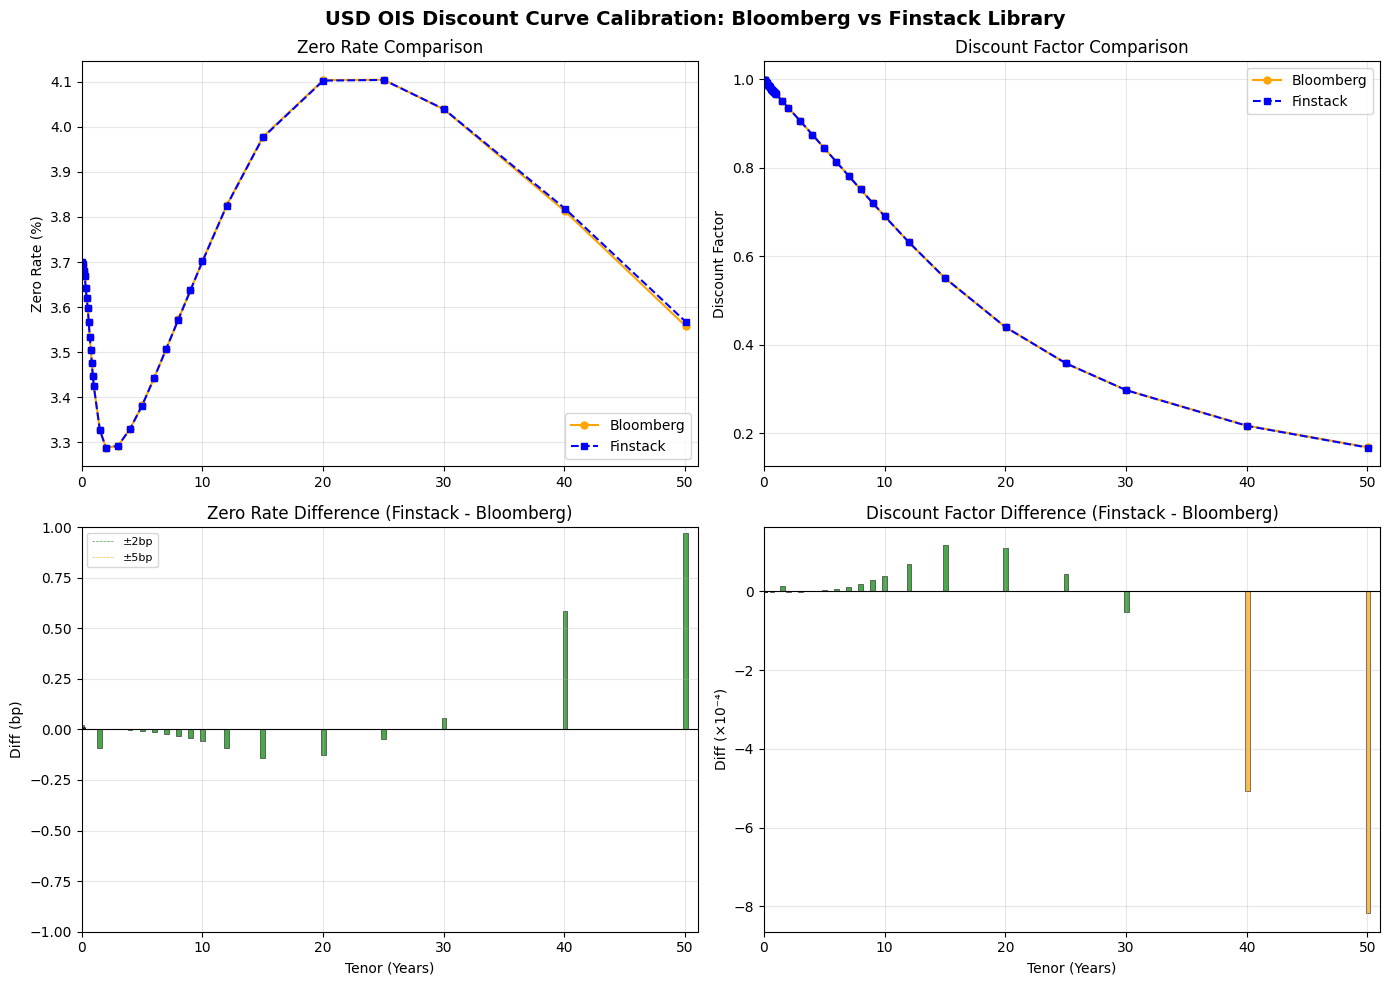


CALIBRATION ACCURACY SUMMARY

Zero Rate Differences (bp):
  Mean:         0.03 bp
  Std Dev:      0.20 bp
  Max Abs:      0.97 bp at 50.0Y

Discount Factor Differences (×10⁻⁴):
  Mean:        -0.29
  Max Abs:      8.18 at 50.0Y


In [10]:
# Plot zero rate and discount factor comparison: Bloomberg vs Finstack
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# Collect data for plotting
tenors = []
bbg_zeros = []
calc_zeros = []
bbg_dfs = []
calc_dfs = []

for mat_date, bbg_zero, bbg_df in bloomberg_data:
    days = (mat_date - base_date).days
    t = days / 365.0
    tenors.append(t)
    bbg_zeros.append(bbg_zero)
    calc_zeros.append(discount_curve.zero_on_date(mat_date) * 100)
    bbg_dfs.append(bbg_df)
    calc_dfs.append(discount_curve.df_on_date(mat_date))

# Top left: Zero rates comparison
ax1.plot(tenors, bbg_zeros, 'o-', color='orange', label='Bloomberg', markersize=5, linewidth=1.5)
ax1.plot(tenors, calc_zeros, 's--', color='blue', label='Finstack', markersize=4, linewidth=1.5)
ax1.set_ylabel('Zero Rate (%)')
ax1.set_title('Zero Rate Comparison')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(tenors) + 1)

# Top right: Discount factor comparison
ax2.plot(tenors, bbg_dfs, 'o-', color='orange', label='Bloomberg', markersize=5, linewidth=1.5)
ax2.plot(tenors, calc_dfs, 's--', color='blue', label='Finstack', markersize=4, linewidth=1.5)
ax2.set_ylabel('Discount Factor')
ax2.set_title('Discount Factor Comparison')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max(tenors) + 1)

# Bottom left: Zero rate difference in bp
zero_diffs_bp = [(c - b) * 100 for c, b in zip(calc_zeros, bbg_zeros)]
colors = ['green' if abs(d) < 2 else 'orange' if abs(d) < 5 else 'red' for d in zero_diffs_bp]
ax3.bar(tenors, zero_diffs_bp, width=0.4, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.axhline(y=2, color='green', linestyle='--', linewidth=0.5, alpha=0.7, label='±2bp')
ax3.axhline(y=-2, color='green', linestyle='--', linewidth=0.5, alpha=0.7)
ax3.axhline(y=5, color='orange', linestyle='--', linewidth=0.5, alpha=0.7, label='±5bp')
ax3.axhline(y=-5, color='orange', linestyle='--', linewidth=0.5, alpha=0.7)
ax3.set_xlabel('Tenor (Years)')
ax3.set_ylabel('Diff (bp)')
ax3.set_title('Zero Rate Difference (Finstack - Bloomberg)')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max(tenors) + 1)
ax3.set_ylim(-1, 1)

# Bottom right: Discount factor difference (in bp equivalent)
df_diffs = [(c - b) * 10000 for c, b in zip(calc_dfs, bbg_dfs)]  # Scale to bp-like units
colors_df = ['green' if abs(d) < 5 else 'orange' if abs(d) < 20 else 'red' for d in df_diffs]
ax4.bar(tenors, df_diffs, width=0.4, color=colors_df, alpha=0.7, edgecolor='black', linewidth=0.5)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Tenor (Years)')
ax4.set_ylabel('Diff (×10⁻⁴)')
ax4.set_title('Discount Factor Difference (Finstack - Bloomberg)')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, max(tenors) + 1)

plt.suptitle('USD OIS Discount Curve Calibration: Bloomberg vs Finstack Library', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("CALIBRATION ACCURACY SUMMARY")
print("="*70)
print(f"\nZero Rate Differences (bp):")
print(f"  Mean:     {sum(zero_diffs_bp)/len(zero_diffs_bp):>8.2f} bp")
print(f"  Std Dev:  {(sum((d - sum(zero_diffs_bp)/len(zero_diffs_bp))**2 for d in zero_diffs_bp)/len(zero_diffs_bp))**0.5:>8.2f} bp")
print(f"  Max Abs:  {max(abs(d) for d in zero_diffs_bp):>8.2f} bp at {tenors[zero_diffs_bp.index(max(zero_diffs_bp, key=abs))]:.1f}Y")
print(f"\nDiscount Factor Differences (×10⁻⁴):")
print(f"  Mean:     {sum(df_diffs)/len(df_diffs):>8.2f}")
print(f"  Max Abs:  {max(abs(d) for d in df_diffs):>8.2f} at {tenors[df_diffs.index(max(df_diffs, key=abs))]:.1f}Y")

## 2. SOFR Forward Curve Calibration (Projection Curve)

Next we calibrate a USD SOFR **3M forward/projection** curve while re-using the already-built **USD-OIS** curve as the discount curve.

The goal is the same as the OIS section: keep a notebook-friendly, *Bloomberg-replaceable* block of quotes and reference values so you can later swap in real BBG quotes + a small “golden” set of expected calibrated outputs.


In [5]:
## 2.1 SOFR 3M forward curve quote set (replaceable with Bloomberg)
#
# This is intentionally a small starter set. Replace these with Bloomberg-sourced
# SOFR 3M instruments (FRAs + swaps) and keep the shape the same.

SOFR_3M_INDEX_ID = "USD-SOFR-3M"

# NOTE: These are placeholders. Swap in Bloomberg maturities + rates.
sofr_3m_forward_quotes = [
    # FRAs (3M forwards starting in 1M / 3M)
    cal.RatesQuote.fra(
        "SOFR3M-FRA-1",
        SOFR_3M_INDEX_ID,
        date(2026, 1, 12),
        date(2026, 4, 13),
        0.03690,
    ),
    cal.RatesQuote.fra(
        "SOFR3M-FRA-2",
        SOFR_3M_INDEX_ID,
        date(2026, 3, 12),
        date(2026, 6, 12),
        0.03625,
    ),
    # Swaps (SOFR 3M par swap quotes)
    cal.RatesQuote.swap(
        "SOFR3M-SWAP-2Y",
        SOFR_3M_INDEX_ID,
        date(2027, 12, 13),
        0.03375,
    ),
    cal.RatesQuote.swap(
        "SOFR3M-SWAP-5Y",
        SOFR_3M_INDEX_ID,
        date(2030, 12, 12),
        0.03410,
    ),
]

# Sanity: the discount curve needed for forward curve pricing must already exist.
_ = market.discount("USD-OIS")
print("Forward curve quotes:", len(sofr_3m_forward_quotes))


Forward curve quotes: 4


In [6]:
## 2.2 Calibrate SOFR 3M forward curve using USD-OIS as discount curve

# We run a separate v2 plan step, re-using the existing MarketContext that already
# contains USD-OIS from Section 1.

sofr_curve_id = "USD-SOFR-3M-FWD"

quote_sets_sofr = {"sofr_3m": [q.to_market_quote() for q in sofr_3m_forward_quotes]}

fwd_step_conventions = {
    "curve_day_count": "act365f",
    "settlement_days": 2,
    "calendar_id": "usny",
    "business_day_convention": "modified_following",
    "allow_calendar_fallback": False,
    # Forward/projection curves typically do not use settlement-start semantics.
    "use_settlement_start": False,
}

steps_sofr = [
    {
        "id": "sofr_3m",
        "quote_set": "sofr_3m",
        "kind": "forward",
        "curve_id": sofr_curve_id,
        "currency": "USD",
        "base_date": str(base_date),
        "tenor_years": 0.25,
        # Critical: use the already-built OIS curve for discounting.
        "discount_curve_id": "USD-OIS",
        # NOTE: v2 GlobalSolve is not supported for forward curve steps yet;
        # using it will raise RuntimeError("Invalid input data").
        "method": "Bootstrap",
        "conventions": fwd_step_conventions,
        "interpolation": "linear",
    }
]

market, plan_report_sofr, step_reports_sofr = cal.execute_calibration_v2(
    "notebook_sofr_3m_forward_curve",
    quote_sets_sofr,
    steps_sofr,
    settings=settings,
    initial_market=market,
)

sofr_fwd_curve = market.forward(sofr_curve_id)
sofr_fwd_report = step_reports_sofr["sofr_3m"]

print("SOFR forward curve calibrated:", sofr_fwd_curve.id)
print("Plan success:", plan_report_sofr.success)
print("Step success:", sofr_fwd_report.success)
print("Max residual:", sofr_fwd_report.max_residual)
print("RMSE:", sofr_fwd_report.rmse)
print("Number of knots:", len(sofr_fwd_curve.points))

_top = sorted(sofr_fwd_report.residuals.items(), key=lambda kv: abs(kv[1]), reverse=True)[:10]
print("\nTop residuals (abs):")
for k, v in _top:
    print(f"  {k}: {v:.3e}")

print("\nSample forward rates:")
for t in [0.25, 0.5, 1.0, 2.0, 5.0]:
    print(f"  f({t:>4.2f}y): {sofr_fwd_curve.rate(t) * 100:>8.4f}%")


SOFR forward curve calibrated: USD-SOFR-3M-FWD
Plan success: True
Step success: True
Max residual: 8.310019339319297e-13
RMSE: 4.286191137583484e-13
Number of knots: 5

Top residuals (abs):
  quote_000003: 8.310e-13
  quote_000001: 1.944e-13
  quote_000002: -8.064e-14
  quote_000000: -0.000e+00

Sample forward rates:
  f(0.25y):   3.6900%
  f(0.50y):   3.5033%
  f(1.00y):   3.8278%
  f(2.00y):   4.5188%
  f(5.00y):   3.3257%


In [7]:
## 2.3 Bloomberg-replaceable check: forward curve fwd rates + implied projection DFs
#
# Bloomberg forward/projection curves are often validated by checking BOTH:
# - forward rates, and
# - curve discount factors (projection discount factors implied by the forward curve).
#
# In finstack-py the calibrated projection curve is a ForwardCurve (time -> forward rate).



# (t_years, expected_forward_rate_pct, expected_projection_df)
sofr_3m_bbg_reference = [
    # Example placeholders — replace with Bloomberg.
    (0.25, 3.6900, 0.990900),
    (0.50, 3.6250, 0.982000),
    (1.00, 3.5000, 0.965000),
    (2.00, 3.4000, 0.936000),
    (5.00, 3.6000, 0.844000),
]

print(
    f"{'t (y)':>6} {'BBG fwd%':>10} {'Calc fwd%':>11} {'Diff (bp)':>10}"
    f" {'BBG DF':>10} {'Calc DF':>10} {'DF Diff':>10}"
)
print("-" * 78)

max_abs_fwd_bp = 0.0
max_abs_df = 0.0

for t, bbg_fwd_pct, bbg_df in sofr_3m_bbg_reference:
    calc_fwd_pct = sofr_fwd_curve.rate(float(t)) * 100.0
    fwd_diff_bp = (calc_fwd_pct - float(bbg_fwd_pct)) * 100.0
    max_abs_fwd_bp = max(max_abs_fwd_bp, abs(fwd_diff_bp))

    calc_df = sofr_fwd_curve.df(float(t))
    df_diff = calc_df - float(bbg_df)
    max_abs_df = max(max_abs_df, abs(df_diff))

    print(
        f"{t:>6.2f} {bbg_fwd_pct:>10.5f} {calc_fwd_pct:>11.5f} {fwd_diff_bp:>10.2f}"
        f" {bbg_df:>10.6f} {calc_df:>10.6f} {df_diff:>10.6f}"
    )

 t (y)   BBG fwd%   Calc fwd%  Diff (bp)     BBG DF    Calc DF    DF Diff
------------------------------------------------------------------------------
  0.25    3.69000     3.69000       0.00   0.990900   0.990859  -0.000041
  0.50    3.62500     3.50333     -12.17   0.982000   0.981942  -0.000058
  1.00    3.50000     3.82782      32.78   0.965000   0.964237  -0.000763
  2.00    3.40000     4.51882     111.88   0.936000   0.925025  -0.010975
  5.00    3.60000     3.32575     -27.43   0.844000   0.822333  -0.021667


## 2.4 Plot: Bloomberg vs Finstack (SOFR 3M Forward + Projection DF)

This mirrors the OIS 4‑panel plot above, but for the SOFR 3M projection curve:
- Forward rates
- Implied projection discount factors
- Differences


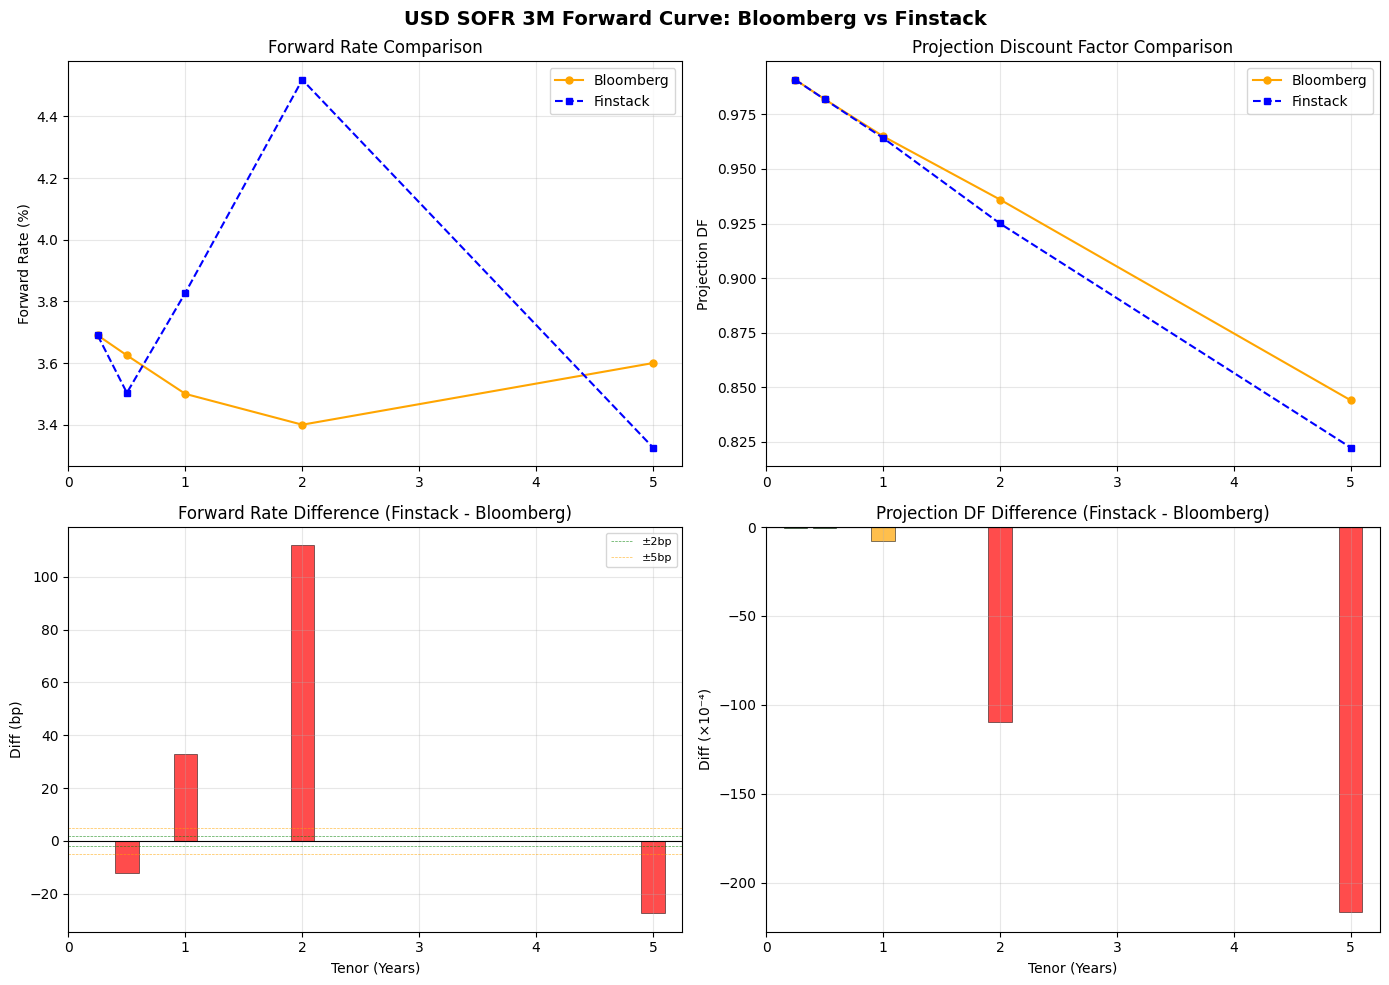


SOFR 3M FORWARD CURVE ACCURACY SUMMARY

Forward Rate Differences (bp):
  Mean:        21.01 bp
  Max Abs:    111.88 bp at 2.00Y

Projection DF Differences (×10⁻⁴):
  Mean:       -67.01
  Max Abs:    216.67 at 5.00Y


In [8]:
# 4-panel plot: Bloomberg vs Finstack for SOFR 3M forward + implied projection DF
import matplotlib.pyplot as plt

# Expect these from previous cells:
# - base_date
# - sofr_fwd_curve
# - sofr_3m_bbg_reference: [(t_years, bbg_fwd_pct, bbg_df), ...]

if "sofr_3m_bbg_reference" not in globals():
    raise RuntimeError("sofr_3m_bbg_reference not found; run the Bloomberg reference cell first")

# Collect data
sofr_t = []
bbg_fwd = []
calc_fwd = []
bbg_df = []
calc_df = []

for t_years, bbg_fwd_pct, bbg_df_val in sofr_3m_bbg_reference:
    t = float(t_years)
    sofr_t.append(t)

    bbg_fwd.append(float(bbg_fwd_pct))
    calc_fwd.append(sofr_fwd_curve.rate(t) * 100.0)

    bbg_df.append(float(bbg_df_val))
    calc_df.append(sofr_fwd_curve.df(t))

# Diffs
fwd_diffs_bp = [(c - b) * 100.0 for c, b in zip(calc_fwd, bbg_fwd)]
df_diffs = [c - b for c, b in zip(calc_df, bbg_df)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# Top left: forward rates
ax1.plot(sofr_t, bbg_fwd, 'o-', color='orange', label='Bloomberg', markersize=5, linewidth=1.5)
ax1.plot(sofr_t, calc_fwd, 's--', color='blue', label='Finstack', markersize=4, linewidth=1.5)
ax1.set_ylabel('Forward Rate (%)')
ax1.set_title('Forward Rate Comparison')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(sofr_t) + 0.25)

# Top right: implied projection DF
ax2.plot(sofr_t, bbg_df, 'o-', color='orange', label='Bloomberg', markersize=5, linewidth=1.5)
ax2.plot(sofr_t, calc_df, 's--', color='blue', label='Finstack', markersize=4, linewidth=1.5)
ax2.set_ylabel('Projection DF')
ax2.set_title('Projection Discount Factor Comparison')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max(sofr_t) + 0.25)

# Bottom left: forward diff (bp)
colors = ['green' if abs(d) < 2 else 'orange' if abs(d) < 5 else 'red' for d in fwd_diffs_bp]
ax3.bar(sofr_t, fwd_diffs_bp, width=0.20, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.axhline(y=2, color='green', linestyle='--', linewidth=0.5, alpha=0.7, label='±2bp')
ax3.axhline(y=-2, color='green', linestyle='--', linewidth=0.5, alpha=0.7)
ax3.axhline(y=5, color='orange', linestyle='--', linewidth=0.5, alpha=0.7, label='±5bp')
ax3.axhline(y=-5, color='orange', linestyle='--', linewidth=0.5, alpha=0.7)
ax3.set_xlabel('Tenor (Years)')
ax3.set_ylabel('Diff (bp)')
ax3.set_title('Forward Rate Difference (Finstack - Bloomberg)')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max(sofr_t) + 0.25)

# Bottom right: DF diff (×1e4)
df_diffs_1e4 = [d * 10000.0 for d in df_diffs]
colors_df = ['green' if abs(d) < 5 else 'orange' if abs(d) < 20 else 'red' for d in df_diffs_1e4]
ax4.bar(sofr_t, df_diffs_1e4, width=0.20, color=colors_df, alpha=0.7, edgecolor='black', linewidth=0.5)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Tenor (Years)')
ax4.set_ylabel('Diff (×10⁻⁴)')
ax4.set_title('Projection DF Difference (Finstack - Bloomberg)')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, max(sofr_t) + 0.25)

plt.suptitle('USD SOFR 3M Forward Curve: Bloomberg vs Finstack', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Quick summary stats
print("\n" + "=" * 70)
print("SOFR 3M FORWARD CURVE ACCURACY SUMMARY")
print("=" * 70)
print("\nForward Rate Differences (bp):")
print(f"  Mean:     {sum(fwd_diffs_bp)/len(fwd_diffs_bp):>8.2f} bp")
print(f"  Max Abs:  {max(abs(d) for d in fwd_diffs_bp):>8.2f} bp at {sofr_t[max(range(len(fwd_diffs_bp)), key=lambda i: abs(fwd_diffs_bp[i]))]:.2f}Y")
print("\nProjection DF Differences (×10⁻⁴):")
print(f"  Mean:     {sum(df_diffs_1e4)/len(df_diffs_1e4):>8.2f}")
print(f"  Max Abs:  {max(abs(d) for d in df_diffs_1e4):>8.2f} at {sofr_t[max(range(len(df_diffs_1e4)), key=lambda i: abs(df_diffs_1e4[i]))]:.2f}Y")
